# 02_eda.ipynb

## Research focus for EDA

This notebook performs exploratory data analysis (EDA) for:

- **Behavior variable:** `CurrentCigaretteUse`
- **Continuous variable:** `BMIPCT`

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

# Load both cleaned and recoded data
df_clean = pd.read_csv("../data/processed/yrbs_cleaned.csv")
df = pd.read_csv("../data/processed/yrbs_recoded.csv")

print("Cleaned data shape:", df_clean.shape)
print("Recoded data shape:", df.shape)

Cleaned data shape: (14041, 103)
Recoded data shape: (14041, 103)


In [2]:
# Original code frequencies for CurrentCigaretteUse
original_behavior = pd.to_numeric(df_clean["CurrentCigaretteUse"], errors="coerce")

original_behavior_table = (
    original_behavior.value_counts(dropna=False)
    .sort_index()
    .rename_axis("original_code")
    .reset_index(name="count")
)

original_behavior_table["proportion"] = original_behavior_table["count"] / original_behavior_table["count"].sum()
original_behavior_table

,original_code,count,proportion
0,1.0,10734,0.764475
1,2.0,753,0.053629
2,3.0,375,0.026707
3,4.0,250,0.017805
4,5.0,295,0.021010
5,6.0,229,0.016309
6,7.0,687,0.048928
7,NaN,718,0.051136


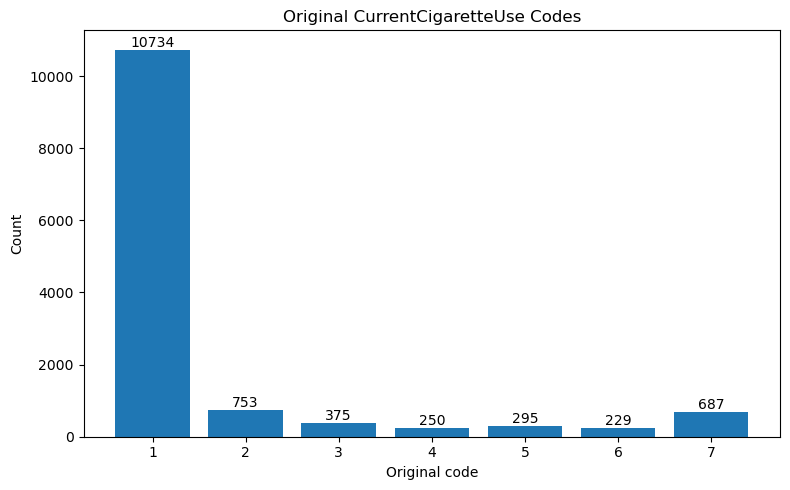

In [3]:
# Bar chart of original CurrentCigaretteUse categories
orig_counts = original_behavior.dropna().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(orig_counts.index.astype(int).astype(str), orig_counts.values)
ax.set_title("Original CurrentCigaretteUse Codes")
ax.set_xlabel("Original code")
ax.set_ylabel("Count")

for i, v in enumerate(orig_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [4]:
# Load the recoded dataset produced in 01_data_check.ipynb
df = pd.read_csv("../data/processed/yrbs_recoded.csv")

print("Dataset shape:", df.shape)
print("\nSelected columns preview:")
display(df[["CurrentCigaretteUse", "BMIPCT", "HowOldAreYou", "Sleep"]].head())

Dataset shape: (14041, 103)

Selected columns preview:


,CurrentCigaretteUse,BMIPCT,HowOldAreYou,Sleep
0,1.0,NaN,4.0,5.0
1,NaN,66.531824,7.0,4.0
2,NaN,NaN,NaN,1.0
3,0.0,98.174319,1.0,1.0
4,0.0,NaN,1.0,NaN


## Variable definitions

### 1. Behavior variable: `CurrentCigaretteUse`
This is the behavior variable for the population proportion analysis.

For this project, it is recoded as:
- **1 = success**: current cigarette use (original codes 2–7)
- **0 = failure**: no current cigarette use (original code 1)

So in this project, **success means the student currently uses cigarettes**.

### 2. Continuous variable: `BMIPCT`
This is the continuous variable for the population mean analysis.

It is analyzed as a numeric variable, and the benchmark for the later one-sample mean test is:
- **μ0 = 65.0**

### 3. Additional EDA variables
- `HowOldAreYou` will be explored with `CurrentCigaretteUse`
- `Sleep` will be explored with `BMIPCT`

These extra EDA checks help us better understand patterns in the data before running one-sample inference.

In [5]:
# Make sure required columns exist
required_cols = ["CurrentCigaretteUse", "BMIPCT", "HowOldAreYou", "Sleep"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Coerce to numeric where appropriate
for col in ["CurrentCigaretteUse", "BMIPCT", "HowOldAreYou", "Sleep"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[required_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14041 entries, 0 to 14040
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CurrentCigaretteUse  13323 non-null  float64
 1   BMIPCT               13062 non-null  float64
 2   HowOldAreYou         13980 non-null  float64
 3   Sleep                12154 non-null  float64
dtypes: float64(4)
memory usage: 438.9 KB
None


### Missing-value check 


In [6]:
# Missing value check for key variables
missing_summary = pd.DataFrame({
    "variable": required_cols,
    "missing_count": [df[col].isna().sum() for col in required_cols],
    "non_missing_count": [df[col].notna().sum() for col in required_cols]
})

missing_summary

,variable,missing_count,non_missing_count
0,CurrentCigaretteUse,718,13323
1,BMIPCT,979,13062
2,HowOldAreYou,61,13980
3,Sleep,1887,12154


In [7]:
# Behavior variable EDA dataset
behavior = df["CurrentCigaretteUse"].dropna()

print("Behavior variable sample size:", behavior.shape[0])
print("\nValue counts:")
print(behavior.value_counts(dropna=False).sort_index())

Behavior variable sample size: 13323

Value counts:
CurrentCigaretteUse
0.0    10734
1.0     2589
Name: count, dtype: int64


In [8]:
# Frequency and proportion table for the recoded behavior variable
behavior_table = behavior.value_counts().sort_index().rename_axis("CurrentCigaretteUse_recoded").reset_index(name="count")
behavior_table["proportion"] = behavior_table["count"] / behavior_table["count"].sum()

# Map labels for readability
label_map = {0: "Failure (No current cigarette use)", 1: "Success (Current cigarette use)"}
behavior_table["label"] = behavior_table["CurrentCigaretteUse_recoded"].map(label_map)

behavior_table = behavior_table[["CurrentCigaretteUse_recoded", "label", "count", "proportion"]]
behavior_table

,CurrentCigaretteUse_recoded,label,count,proportion
0,0.0,Failure (No current cigarette use),10734,0.805674
1,1.0,Success (Current cigarette use),2589,0.194326


In [9]:
# Sample proportion of current cigarette use
p_hat = behavior.mean()

print(f"Sample proportion (p-hat) for CurrentCigaretteUse = {p_hat:.4f}")
print("Benchmark proportion for later one-sample test: p0 = 0.20")

Sample proportion (p-hat) for CurrentCigaretteUse = 0.1943
Benchmark proportion for later one-sample test: p0 = 0.20


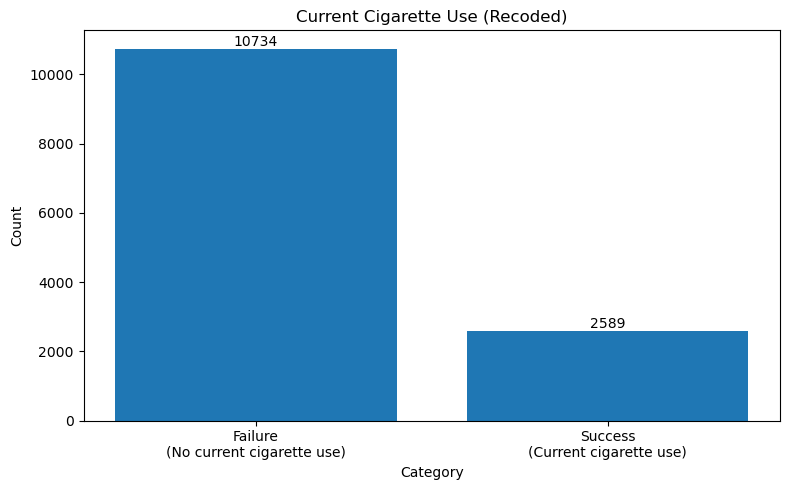

In [10]:
# Save bar chart for behavior variable
behavior_counts = behavior.value_counts().sort_index()
x_labels = ["Failure\n(No current cigarette use)", "Success\n(Current cigarette use)"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_labels, behavior_counts.values)
ax.set_title("Current Cigarette Use (Recoded)")
ax.set_ylabel("Count")
ax.set_xlabel("Category")

for i, v in enumerate(behavior_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("../outputs/figures/behavior_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of the behavior bar chart

This indicates that the majority of students in the sample do not currently use cigarettes, while a smaller proportion report current use.

In [11]:
# Continuous variable EDA dataset
continuous = df["BMIPCT"].dropna()

print("Continuous variable sample size:", continuous.shape[0])
print("\nDescriptive statistics for BMIPCT:")
continuous.describe()

Continuous variable sample size: 13062

Descriptive statistics for BMIPCT:


count    1.306200e+04
mean     6.482068e+01
std      2.751676e+01
min      3.720000e-09
25%      4.516627e+01
50%      7.013853e+01
75%      8.945097e+01
max      9.993921e+01
Name: BMIPCT, dtype: float64

In [12]:
# Detailed summary statistics for BMIPCT
bmipct_summary = pd.DataFrame({
    "statistic": [
        "n", "mean", "median", "std", "min", "q1", "q3", "max"
    ],
    "value": [
        continuous.shape[0],
        continuous.mean(),
        continuous.median(),
        continuous.std(ddof=1),
        continuous.min(),
        continuous.quantile(0.25),
        continuous.quantile(0.75),
        continuous.max()
    ]
})

bmipct_summary

,statistic,value
0,n,1.306200e+04
1,mean,6.482068e+01
2,median,7.013853e+01
3,std,2.751676e+01
4,min,3.720000e-09
5,q1,4.516627e+01
6,q3,8.945097e+01
7,max,9.993921e+01


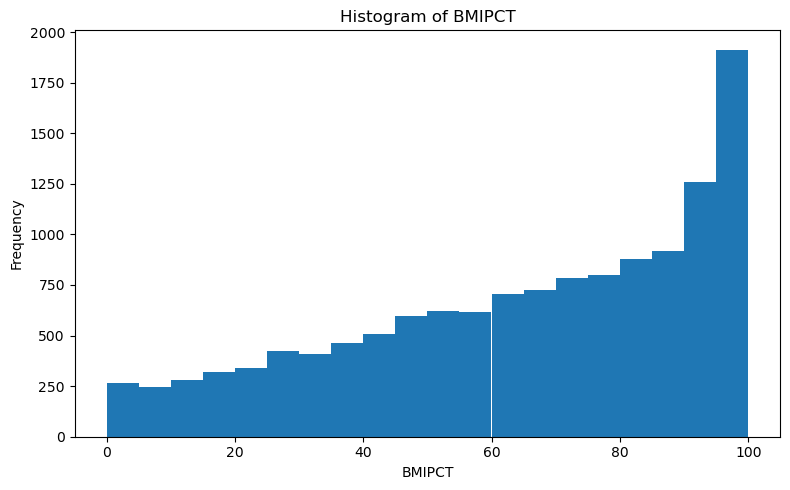

In [13]:
# Histogram for BMIPCT
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(continuous, bins=20)
ax.set_title("Histogram of BMIPCT")
ax.set_xlabel("BMIPCT")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../outputs/figures/continuous_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of the histogram

The values of BMIPCT range approximately from 0 to 100, which is expected for a percentile measure.
The distribution is not symmetric and appears left-skewed (negatively skewed), meaning a large number of observations are concentrated at higher BMI percentiles (around 70–100), And fewer observations are found at the lower end of the scale.

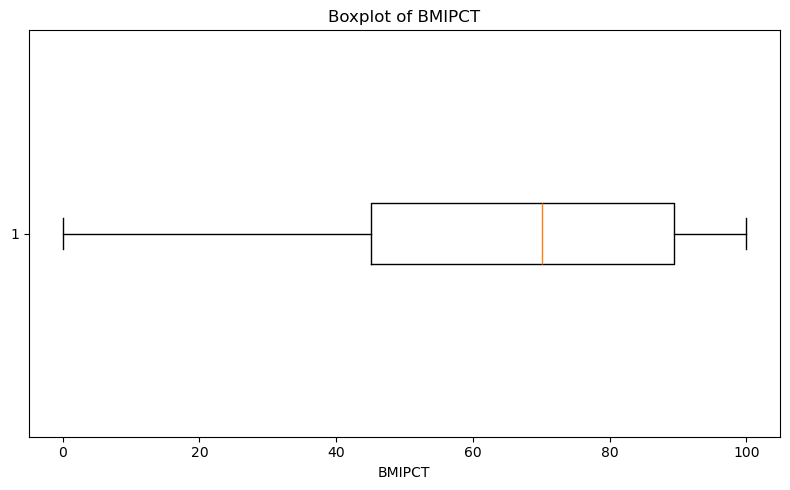

In [14]:
# Boxplot for BMIPCT
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(continuous.dropna(), vert=False)
ax.set_title("Boxplot of BMIPCT")
ax.set_xlabel("BMIPCT")

plt.tight_layout()
plt.show()

In [15]:
# Outlier check using IQR rule
q1 = continuous.quantile(0.25)
q3 = continuous.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (continuous < lower_bound) | (continuous > upper_bound)
outlier_count = outlier_mask.sum()

print(f"Q1 = {q1:.2f}")
print(f"Q3 = {q3:.2f}")
print(f"IQR = {iqr:.2f}")
print(f"Lower bound = {lower_bound:.2f}")
print(f"Upper bound = {upper_bound:.2f}")
print(f"Number of possible outliers = {outlier_count}")

Q1 = 45.17
Q3 = 89.45
IQR = 44.28
Lower bound = -21.26
Upper bound = 155.88
Number of possible outliers = 0


### Interpretation of the boxplot and outlier check

This indicates that a large portion of students have moderate to high BMI percentiles.
There is substantial variability in BMI percentile across students.
The median being above 65 suggests that the typical student in the sample has a BMIPCT higher than the benchmark value (μ₀ = 65.0).

## Additional EDA 1: `HowOldAreYou` with `CurrentCigaretteUse`

This is an additional EDA exploration required by the project.

We compare age patterns across the recoded cigarette-use variable to see whether current cigarette use appears more common in some age groups.


In [16]:
# Cross-tab: HowOldAreYou with CurrentCigaretteUse
age_behavior_df = df[["HowOldAreYou", "CurrentCigaretteUse"]].dropna().copy()

age_behavior_counts = pd.crosstab(age_behavior_df["HowOldAreYou"], age_behavior_df["CurrentCigaretteUse"])
age_behavior_props = pd.crosstab(
    age_behavior_df["HowOldAreYou"], 
    age_behavior_df["CurrentCigaretteUse"], 
    normalize="index"
)

print("Counts table:")
display(age_behavior_counts)

print("\nRow proportions table:")
display(age_behavior_props)

Counts table:


CurrentCigaretteUse,0.0,1.0
HowOldAreYou,,
1.0,9,7
2.0,5,0
3.0,1171,136
4.0,2626,457
5.0,2760,662
6.0,2636,761
7.0,1489,550



Row proportions table:


CurrentCigaretteUse,0.0,1.0
HowOldAreYou,,
1.0,0.562500,0.437500
2.0,1.000000,0.000000
3.0,0.895945,0.104055
4.0,0.851768,0.148232
5.0,0.806546,0.193454
6.0,0.775979,0.224021
7.0,0.730260,0.269740


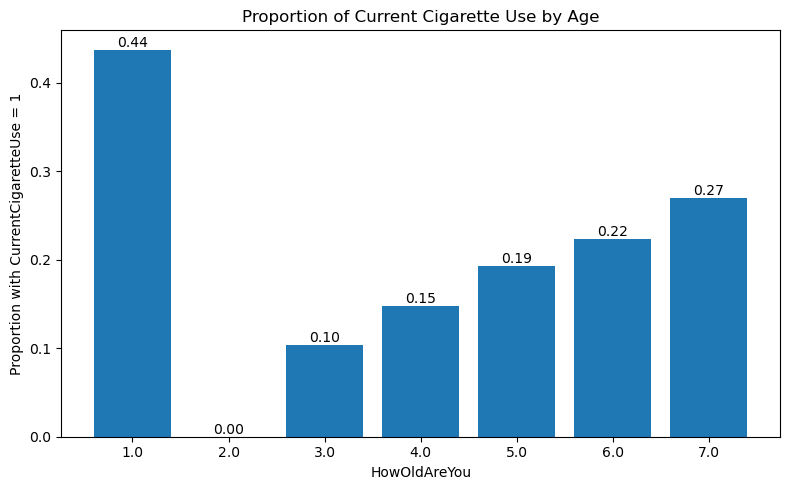

In [17]:
# Plot proportion of current cigarette use by age
prop_by_age = age_behavior_df.groupby("HowOldAreYou")["CurrentCigaretteUse"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(prop_by_age.index.astype(str), prop_by_age.values)
ax.set_title("Proportion of Current Cigarette Use by Age")
ax.set_xlabel("HowOldAreYou")
ax.set_ylabel("Proportion with CurrentCigaretteUse = 1")

for i, v in enumerate(prop_by_age.values):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Interpretation of `HowOldAreYou` with `CurrentCigaretteUse`

This pattern suggests that older students are more likely to report current cigarette use compared to younger students. The increasing trend indicates that age may be an important factor associated with cigarette use behavior.

## Additional EDA 2: `Sleep` with `BMIPCT`

This is the second additional EDA exploration.

We explore how `Sleep` varies with `BMIPCT` to better understand the continuous variable in context.

### Why do this before the one-sample mean test?
The later one-sample t-test asks only whether the mean `BMIPCT` differs from **65.0**.

But EDA can reveal whether:
- `BMIPCT` tends to differ across sleep levels,
- the distribution of `BMIPCT` looks similar across sleep groups,
- or some sleep categories contain unusually high or low BMI percentiles.

This does **not** change the one-sample benchmark test, but it improves interpretation of the mean analysis.

In [18]:
# Explore Sleep with BMIPCT
sleep_bmi_df = df[["Sleep", "BMIPCT"]].dropna().copy()

sleep_bmi_summary = sleep_bmi_df.groupby("Sleep")["BMIPCT"].agg(
    n="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).reset_index()

sleep_bmi_summary

,Sleep,n,mean,median,std,min,max
0,1.0,687,67.902050,75.239844,28.463967,3.720000e-09,99.915189
1,2.0,1153,66.220058,72.138336,27.373247,6.954975e-01,99.916460
2,3.0,2576,65.452340,70.872706,27.273065,5.978420e-04,99.843860
3,4.0,3403,65.041944,69.595729,26.695227,8.377636e-03,99.939213
4,5.0,2618,64.245340,69.897469,27.843420,2.250000e-06,99.925951
5,6.0,691,64.153521,70.406041,28.759972,1.090000e-06,99.849540
6,7.0,216,66.665256,75.035475,28.733506,2.621113e-02,99.693536


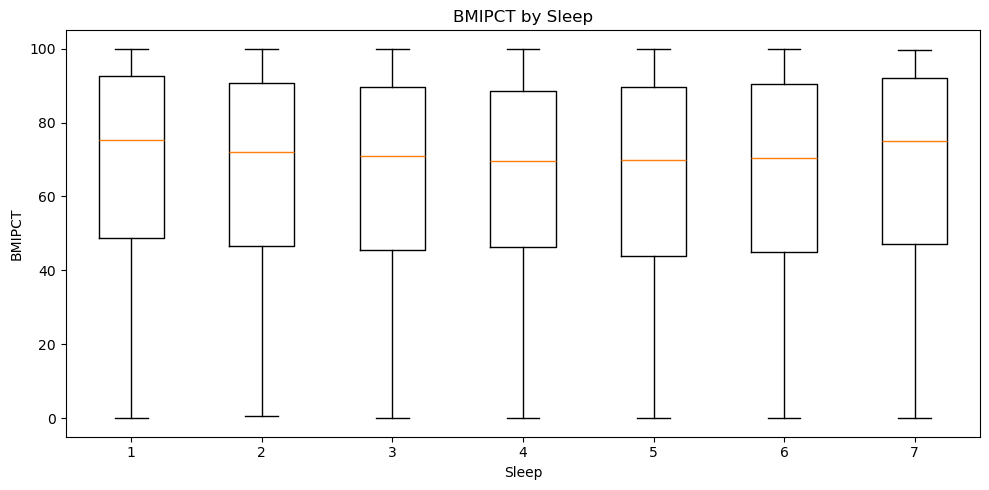

In [19]:
# Boxplot of BMIPCT by Sleep
sleep_groups = []
sleep_labels = []

for sleep_value in sorted(sleep_bmi_df["Sleep"].unique()):
    sleep_groups.append(sleep_bmi_df.loc[sleep_bmi_df["Sleep"] == sleep_value, "BMIPCT"])
    sleep_labels.append(str(int(sleep_value)) if float(sleep_value).is_integer() else str(sleep_value))

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(sleep_groups, labels=sleep_labels)
ax.set_title("BMIPCT by Sleep")
ax.set_xlabel("Sleep")
ax.set_ylabel("BMIPCT")

plt.tight_layout()
plt.show()

### Interpretation of `Sleep` with `BMIPCT`

This suggests that sleep does not appear to have a strong association with BMI percentile in this dataset. While there are small differences in medians between groups, these differences are relatively minor compared to the overall variability within each group.

In [22]:
# Build summary table for export
eda_summary = pd.DataFrame({
    "analysis_part": [
        "Behavior variable",
        "Behavior variable",
        "Behavior variable",
        "Continuous variable",
        "Continuous variable",
        "Continuous variable",
        "Continuous variable",
        "Continuous variable",
        "Continuous variable",
        "Continuous variable",
        "Additional EDA",
        "Additional EDA"
    ],
    "metric": [
        "Behavior variable name",
        "Valid n",
        "Sample proportion (success=1)",
        "Continuous variable name",
        "Valid n",
        "Mean",
        "Median",
        "Standard deviation",
        "Q1",
        "Q3",
        "Age exploration rows",
        "Sleep exploration rows"
    ],
    "value": [
        "CurrentCigaretteUse",
        int(behavior.shape[0]),
        float(round(p_hat, 6)),
        "BMIPCT",
        int(continuous.shape[0]),
        float(round(continuous.mean(), 6)),
        float(round(continuous.median(), 6)),
        float(round(continuous.std(ddof=1), 6)),
        float(round(continuous.quantile(0.25), 6)),
        float(round(continuous.quantile(0.75), 6)),
        int(age_behavior_df.shape[0]),
        int(sleep_bmi_df.shape[0])
    ]
})

eda_summary

,analysis_part,metric,value
0,Behavior variable,Behavior variable name,CurrentCigaretteUse
1,Behavior variable,Valid n,13323
2,Behavior variable,Sample proportion (success=1),0.194326
3,Continuous variable,Continuous variable name,BMIPCT
4,Continuous variable,Valid n,13062
5,Continuous variable,Mean,64.820683
6,Continuous variable,Median,70.138535
7,Continuous variable,Standard deviation,27.516756
8,Continuous variable,Q1,45.16627
9,Continuous variable,Q3,89.450968


In [23]:
# Save summary table
eda_summary.to_csv("../outputs/tables/eda_summary_table.csv", index=False)

print("Saved files:")
print("- ../outputs/figures/behavior_bar_chart.png")
print("- ../outputs/figures/continuous_histogram.png")
print("- ../outputs/tables/eda_summary_table.csv")

Saved files:
- ../outputs/figures/behavior_bar_chart.png
- ../outputs/figures/continuous_histogram.png
- ../outputs/tables/eda_summary_table.csv


## EDA Conclusions

### Behavior Variable: CurrentCigaretteUse

The recoded bar chart shows that the majority of students **do not currently use cigarettes**, with 10,734 students classified as failure and 2,589 as success. This corresponds to a sample proportion of approximately **0.194**, which is very close to the benchmark value of **0.20**.

The additional EDA by age reveals that the **proportion of current cigarette use increases with age**, suggesting that older students are more likely to report current cigarette use. However, some extreme values (such as 0.44 and 0.00) may be due to **small sample sizes in certain age groups**, and should be interpreted cautiously.

Overall, the behavior variable appears **well-defined and suitable for one-sample proportion inference**, and the observed proportion being close to 0.20 suggests that the inferential result may not show a strong deviation from the benchmark.

---

### Continuous Variable: BMIPCT

The histogram and boxplot show that BMIPCT values range from approximately **0 to 100**, with a **slightly left-skewed distribution**. A large number of observations are concentrated at **higher BMI percentiles**, and the median is around **70**, which is above the benchmark value of **65.0**.

The boxplot indicates a **wide spread**, with the middle 50% of values roughly between **45 and 90**, and no clear extreme outliers. This suggests substantial variability in BMI percentiles across students.

The additional EDA (BMIPCT by Sleep) shows that **BMIPCT distributions are similar across sleep categories**, with no strong trend. This suggests that sleep does not appear to have a strong association with BMI percentile in this dataset.

---

### Overall EDA Insights

From the EDA, we conclude that:

- The **sample proportion of current cigarette use (≈ 0.194)** is very close to the benchmark **0.20**, suggesting only a small difference, if any.
- The **mean BMIPCT is likely above 65.0**, as both the median and most of the distribution lie above this value.
- The behavior variable shows variation across age groups, while the continuous variable shows **high variability but no strong subgroup pattern with sleep**.

These findings provide important context for the inference stage. While EDA alone does not answer the research questions, it suggests:
- the proportion analysis may show **little to no significant difference from the benchmark**, and
- the mean analysis may show a **difference above the benchmark value**.

Formal confidence intervals and hypothesis tests are needed to confirm these observations.